# DEEP LEARNING

## Julián Alberto Uribe Gómez

# 1 - Exploración de datos del proyecto de recaudo web

In [ ]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/2021.deeplearning/main/content/init.py
import init; init.init(force_download=False);

replicating local resources


In [ ]:
# Importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Acceder a los datos vía github
dataset0 = pd.read_csv("https://raw.githubusercontent.com/algoritmomaestro/Proyecto_DeepLearning/refs/heads/main/datos_recaudo_total.csv", usecols=[0,1], engine='python', skipfooter=3)
dataset0.head()

,Fecha_Hora,Valor Pago
0,2018-01-04 14:00:00,119404.0
1,2018-01-04 16:00:00,131766.0
2,2018-01-04 17:00:00,53519.0
3,2018-01-04 19:00:00,244373.0
4,2018-01-04 20:00:00,203402.0


In [ ]:
# Mostrar tipos de datos
print("Tipos de dato:")
display(dataset0.dtypes)
display(dataset0.shape)

Tipos de dato:


,0
Fecha_Hora,object
Valor Pago,float64


(44679, 2)

In [ ]:
# Verificar valores faltantes
print("\nValores faltantes:")
display(dataset0.isnull().sum())


Valores faltantes:


,0
Fecha_Hora,0
Valor Pago,0


In [ ]:
# Mostrar estadisticas descriptivas
print("\nEstadísticas descriptivas:")
display(dataset0.describe())


Estadísticas descriptivas:


,Valor Pago
count,4.467900e+04
mean,1.629765e+08
std,5.988574e+08
min,4.000000e+00
25%,3.185726e+06
50%,1.915014e+07
75%,1.018046e+08
max,3.424056e+10


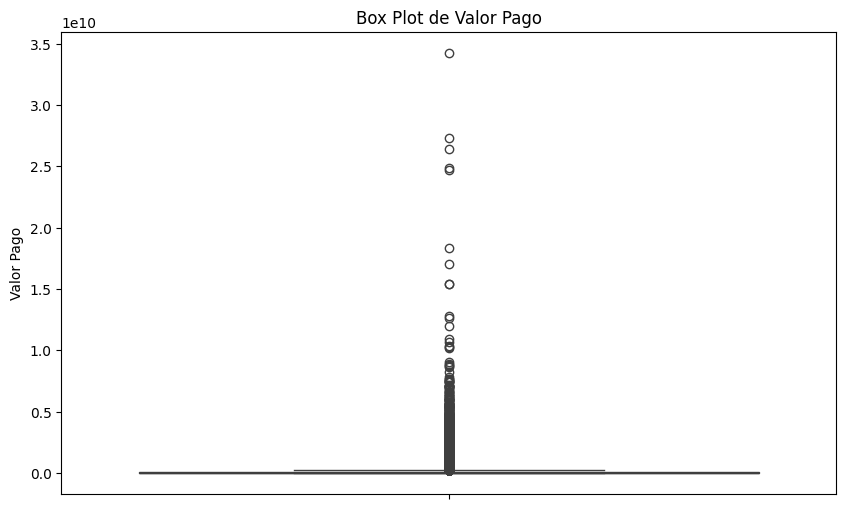

In [ ]:
# Box plot 'Valor Pago'
plt.figure(figsize=(10, 6))
sns.boxplot(y=dataset0['Valor Pago'])
plt.title('Box Plot de Valor Pago')
plt.ylabel('Valor Pago')
plt.show()


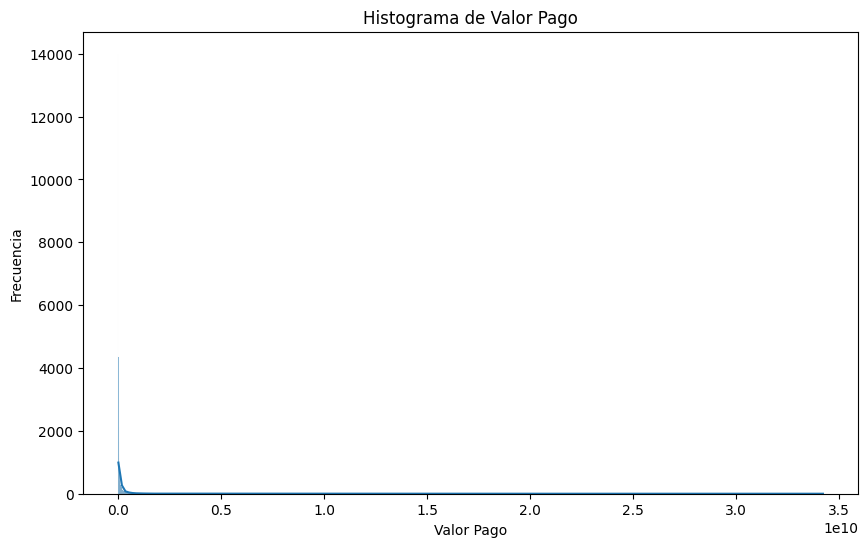

In [ ]:
# Histograma para 'Valor Pago'
plt.figure(figsize=(10, 6))
sns.histplot(dataset0['Valor Pago'], kde=True)
plt.title('Histograma de Valor Pago')
plt.xlabel('Valor Pago')
plt.ylabel('Frecuencia')
plt.show()

## Serie de tiempo recaudo

In [ ]:
# Datos
dataset0 = pd.read_csv("https://raw.githubusercontent.com/algoritmomaestro/Proyecto_DeepLearning/refs/heads/main/datos_recaudo_total.csv", usecols=[0,1], engine='python', skipfooter=3)

In [ ]:
# transformar variable 'Fecha_Hora' a formato datetime
dataset0['Fecha_Hora'] = pd.to_datetime(dataset0['Fecha_Hora'], format='%Y-%m-%d %H:%M:%S')

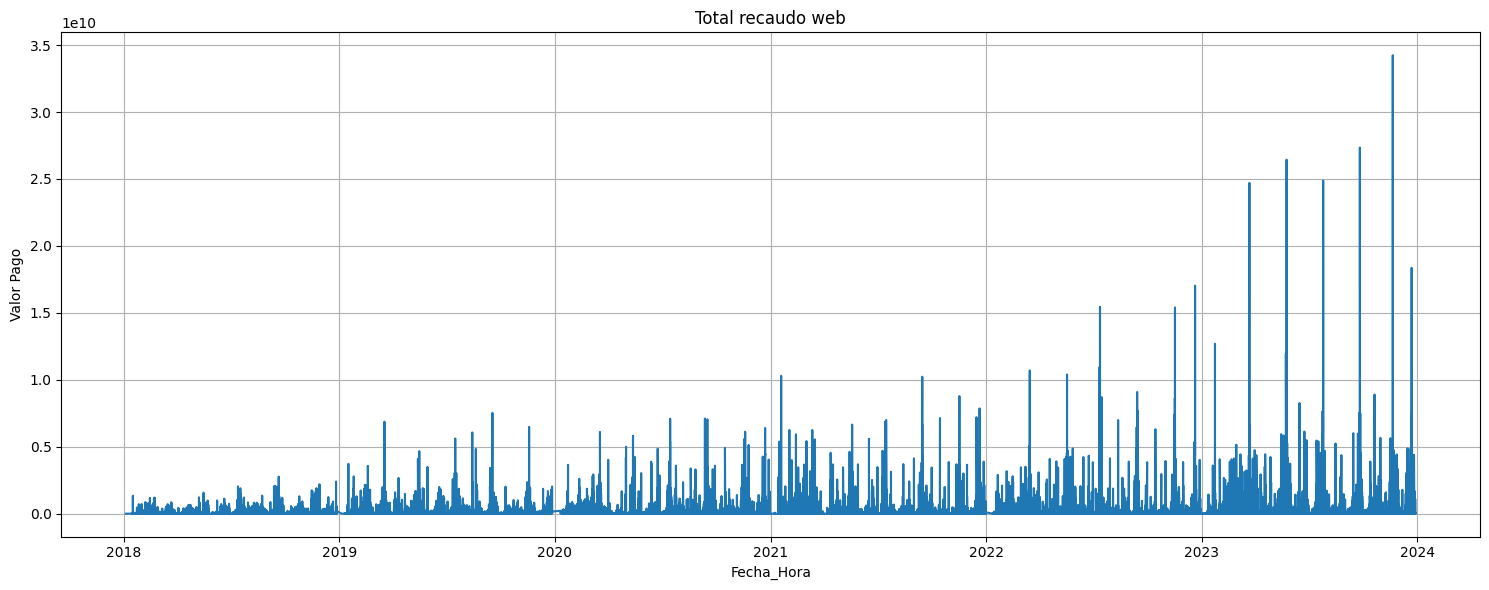

In [ ]:
# Diagrama de línea
plt.figure(figsize=(15, 6))
plt.plot(dataset0['Fecha_Hora'], dataset0['Valor Pago'], linestyle='-')

plt.ylabel('Valor Pago')
plt.xlabel('Fecha_Hora')
plt.title('Total recaudo web')
plt.grid(True)
plt.tight_layout()
plt.show()

### Herramientas clásicas para análisis de series de tiempo

- Autocorrelación y autocorrelación parcial.
- Estacionalidad y temporalidad.

<Figure size 1200x600 with 0 Axes>

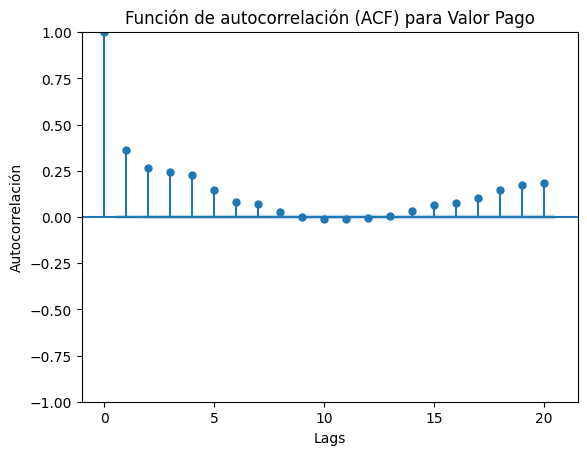

<Figure size 1200x600 with 0 Axes>

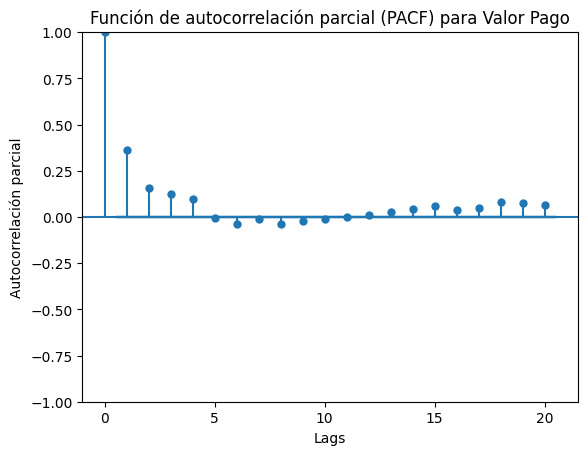

ADF Statistic: -22.887016
p-value: 0.000000
Valores críticos:
	1%: -3.430
	5%: -2.862
	10%: -2.567

La serie de tiempo es estacionaria (p-value <= 0.05).


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Grafico de la función de autocorrelación (ACF)
plt.figure(figsize=(12, 6))
plot_acf(dataset0['Valor Pago'].dropna(), lags=20)
plt.title('Función de autocorrelación (ACF) para Valor Pago')
plt.xlabel('Lags')
plt.ylabel('Autocorrelación')
plt.show()

# Grafico de la función de autocorrelación parcial (PACF)
plt.figure(figsize=(12, 6))
plot_pacf(dataset0['Valor Pago'].dropna(), lags=20)
plt.title('Función de autocorrelación parcial (PACF) para Valor Pago')
plt.xlabel('Lags')
plt.ylabel('Autocorrelación parcial')
plt.show()

# Test de Dickey-Fuller aumentado para estacionalidad
result = adfuller(dataset0['Valor Pago'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Valores críticos:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print("\nLa serie de tiempo es estacionaria (p-value <= 0.05).")
else:
    print("\nLa serie de tiempo no es estacionaria (p-value > 0.05).")

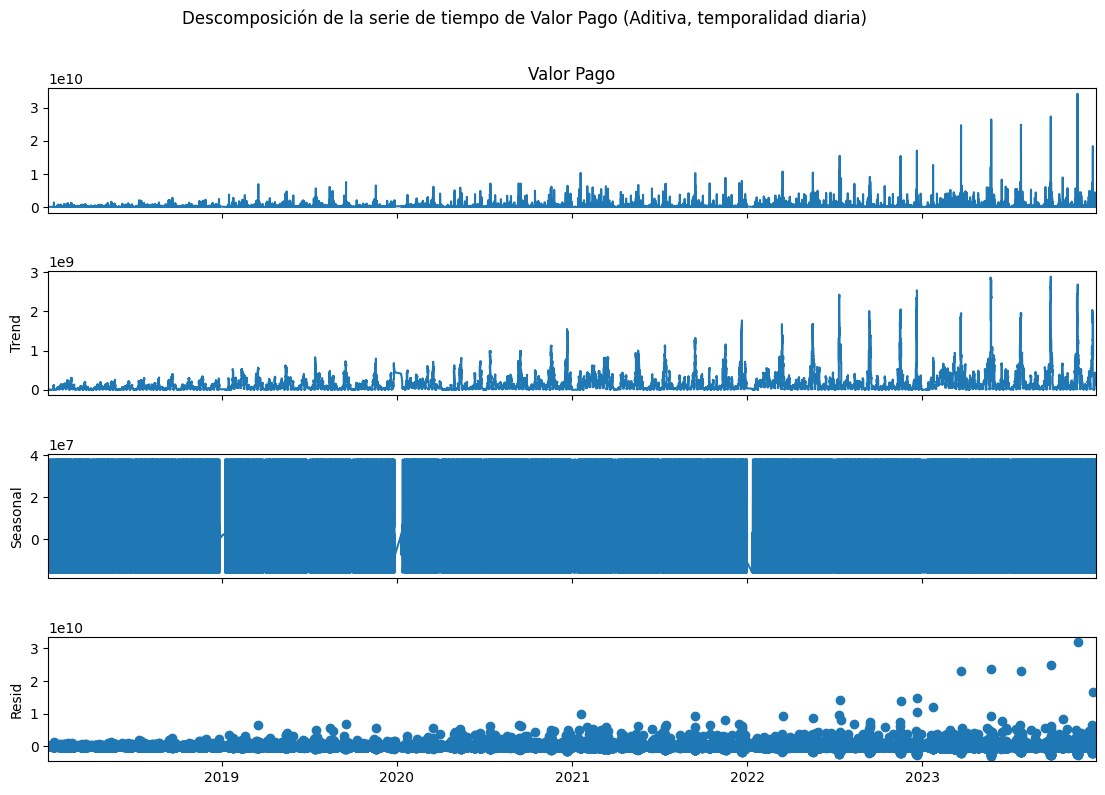

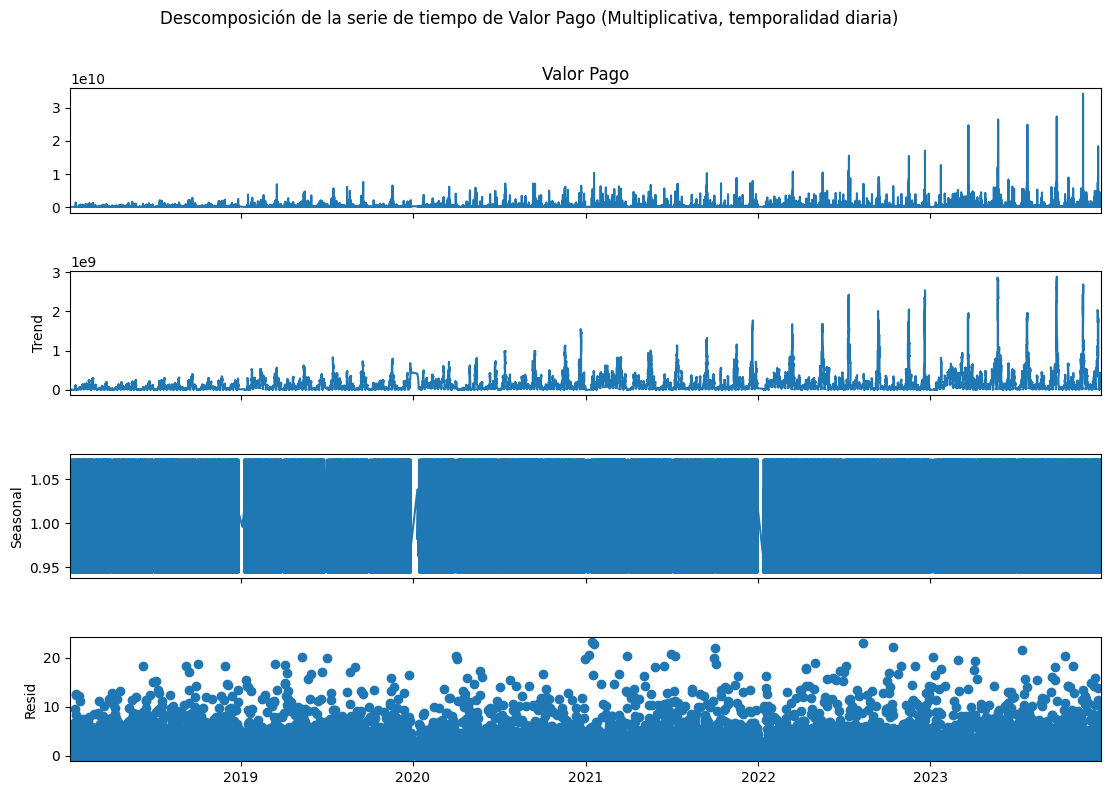

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Suponiendo que la serie temporal tiene una frecuencia,
# Por ejemplo, si los datos son horarios y se sospecha que existe estacionalidad diaria, freq=24
# Si se sospecha que existe estacionalidad semanal, freq=24*7 = 168
# Según el formato "Fecha_Hora" (AAAA-MM-DD HH:MM:SS), los datos parecen ser horarios.
# Primero, se comprueba la estacionalidad diaria (frecuencia = 24 horas).
# Para este ejemplo, supongamos datos horarios con posible estacionalidad diaria (freq=24).

# Preparar 'Fecha_Hora' como index para la descomposición
dataset0_indexed = dataset0.set_index('Fecha_Hora')

# Descomposición aditiva
decomposition = seasonal_decompose(dataset0_indexed['Valor Pago'].dropna(), model='additive', period=24)

# Gráfica
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Descomposición de la serie de tiempo de Valor Pago (Aditiva, temporalidad diaria)', y=1.02)
plt.show()

# Descomposición multiplicativa
decomposition_mult = seasonal_decompose(dataset0_indexed['Valor Pago'].dropna(), model='multiplicative', period=24)
fig_mult = decomposition_mult.plot()
fig_mult.set_size_inches(12, 8)
plt.suptitle('Descomposición de la serie de tiempo de Valor Pago (Multiplicativa, temporalidad diaria)', y=1.02)
plt.show()

### Predicción en la serie temporal utilizando herramientas clásicas

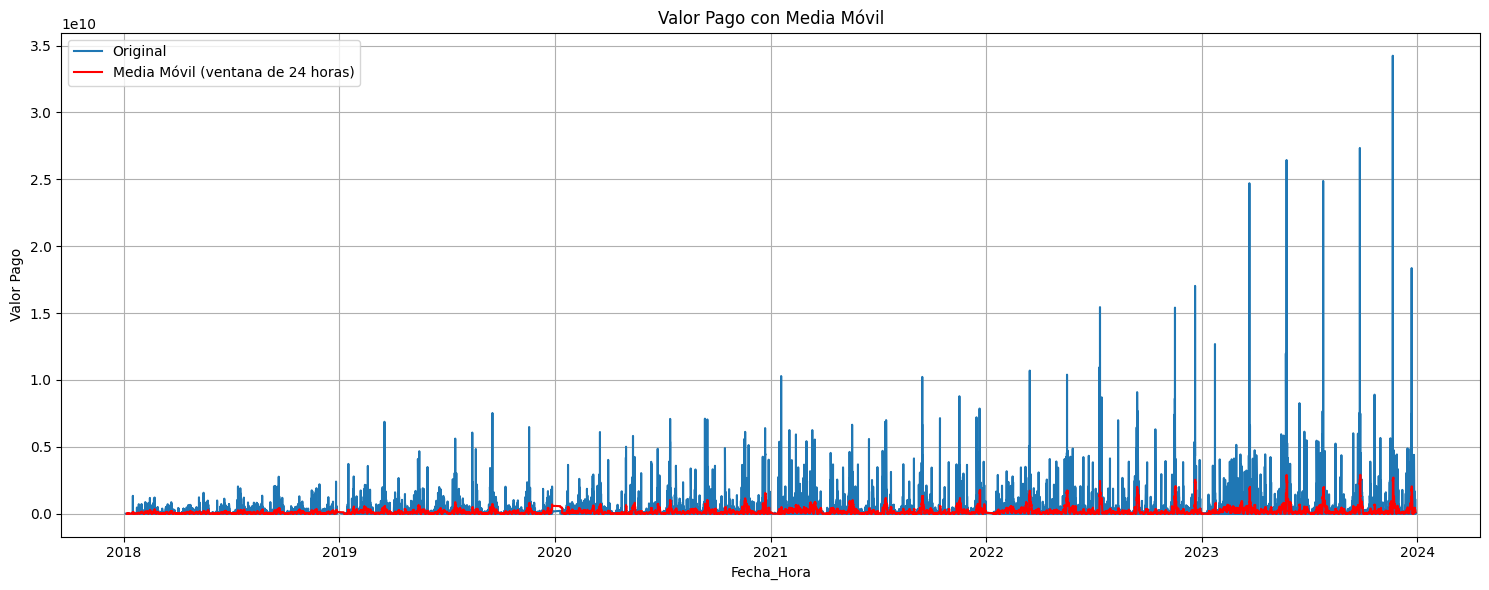

In [ ]:
# Calcular media móvil
rolling_mean = dataset0_indexed['Valor Pago'].rolling(window=24).mean() # Usando una ventana de 24 para patrones diarios

# Graficar la serie de tiempo original junto con la media móvil
plt.figure(figsize=(15, 6))
plt.plot(dataset0_indexed['Valor Pago'], label='Original')
plt.plot(rolling_mean, label='Media Móvil (ventana de 24 horas)', color='red')
plt.title('Valor Pago con Media Móvil')
plt.xlabel('Fecha_Hora')
plt.ylabel('Valor Pago')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Este ejemplo, es para una ventana de 168 para patrones semanales (24 * 7)
# rolling_mean_weekly = dataset0_indexed['Valor Pago'].rolling(window=168).mean()

### Usar la media móvil como una predicción: enfoque muy básico.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from statsmodels.tsa.stattools import acf

# Suponiendo que dataset0_indexed con 'Fecha_Hora' como índice está disponible de pasos anteriores
# Si no, ejecuta la celda que establece 'Fecha_Hora' como índice

# Calcular la media móvil, desplazando por 1 para usar datos pasados para la predicción
rolling_mean_prediction = dataset0_indexed['Valor Pago'].rolling(window=24).mean().shift(1)

# Eliminar los valores NaN creados por la media móvil y el desplazamiento
actual_values = dataset0_indexed['Valor Pago'].dropna()
predicted_values = rolling_mean_prediction.dropna()

# Alinear los valores reales y predichos por índice
common_index = actual_values.index.intersection(predicted_values.index)
actual_values_aligned = actual_values[common_index]
predicted_values_aligned = predicted_values[common_index]

# Crear un DataFrame para comparar valores reales y predichos
comparison_df = pd.DataFrame({
    'Valor Real': actual_values_aligned,
    'Valor Predicho (Media Móvil)': predicted_values_aligned
})

# Mostrar la tabla de comparación
print("\nComparación de Valores Reales vs. Predichos (usando Media Móvil como una predicción simple):")
display(comparison_df.head()) # Mostrar el encabezado de la tabla de comparación
display(comparison_df.tail()) # Mostrar la cola de la tabla de comparación

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(actual_values_aligned, predicted_values_aligned))
print(f"\nRMSE: {rmse:.2f}")

# Calcular MAPE (manejando posible división por cero para actual_values_aligned)
# Añadir un pequeño epsilon para evitar la división por cero
epsilon = 1e-10
mape = np.mean(np.abs((actual_values_aligned - predicted_values_aligned) / (actual_values_aligned + epsilon))) * 100
print(f"MAPE: {mape:.2f}%")

# Calcular MAE
mae = mean_absolute_error(actual_values_aligned, predicted_values_aligned)
print(f"MAE: {mae:.2f}")

# Calcular sMAPE (Symmetric Mean Absolute Percentage Error)
# Añadir un pequeño epsilon para evitar la división por cero en el denominador
smape = np.mean(2 * np.abs(predicted_values_aligned - actual_values_aligned) / (np.abs(actual_values_aligned) + np.abs(predicted_values_aligned) + epsilon)) * 100
print(f"sMAPE: {smape:.2f}%")

# Calcular MASE (Mean Absolute Scaled Error) - requiere calcular una predicción ingenua (por ejemplo, ingenua estacional)
# Para simplificar, usaremos una predicción ingenua del último valor observado como línea base para MASE
# Esto asume una serie de tiempo no estacional o que la estacionalidad relevante es capturada por la ventana de la media móvil
# Un MASE más robusto usaría una predicción ingenua estacional si hay estacionalidad fuerte.
naive_forecast = actual_values_aligned.shift(1).dropna()
actual_values_for_mase = actual_values_aligned[naive_forecast.index]
mae_naive = np.mean(np.abs(actual_values_for_mase - naive_forecast))

# Manejar el caso en que mae_naive sea cero para evitar errores de división
if mae_naive == 0:
    mase = np.nan # MASE es indefinido si la predicción ingenua tiene error cero
    print("MASE: Indefinido (La predicción ingenua tiene error cero)")
else:
    mase = mae / mae_naive
    print(f"MASE: {mase:.2f}")

# Calcular R-squared
r2 = r2_score(actual_values_aligned, predicted_values_aligned)
print(f"R-squared: {r2:.2f}")


# Nota: Usar la media móvil como una predicción directa es un enfoque muy básico.
# Normalmente se necesitan modelos de series de tiempo más sofisticados para una previsión precisa.


Comparación de Valores Reales vs. Predichos (usando Media Móvil como una predicción simple):


,Valor Real,Valor Predicho (Media Móvil)
Fecha_Hora,,
2018-01-06 13:00:00,1891490.0,239724.625000
2018-01-06 14:00:00,1787234.0,313561.541667
2018-01-06 15:00:00,77910.0,382539.375000
2018-01-06 18:00:00,649744.0,383555.666667
2018-01-06 20:00:00,243808.0,400446.125000


,Valor Real,Valor Predicho (Media Móvil)
Fecha_Hora,,
2023-12-28 19:00:00,183710.0,1.415924e+08
2023-12-28 20:00:00,186502.0,1.345048e+08
2023-12-28 21:00:00,1344309.0,1.267904e+08
2023-12-28 22:00:00,1937523.0,1.267873e+08
2023-12-28 23:00:00,1175023.0,1.207862e+08



RMSE: 572096551.13
MAPE: 105804.73%
MAE: 186288841.45
sMAPE: 114.99%
MASE: 1.18
R-squared: 0.09


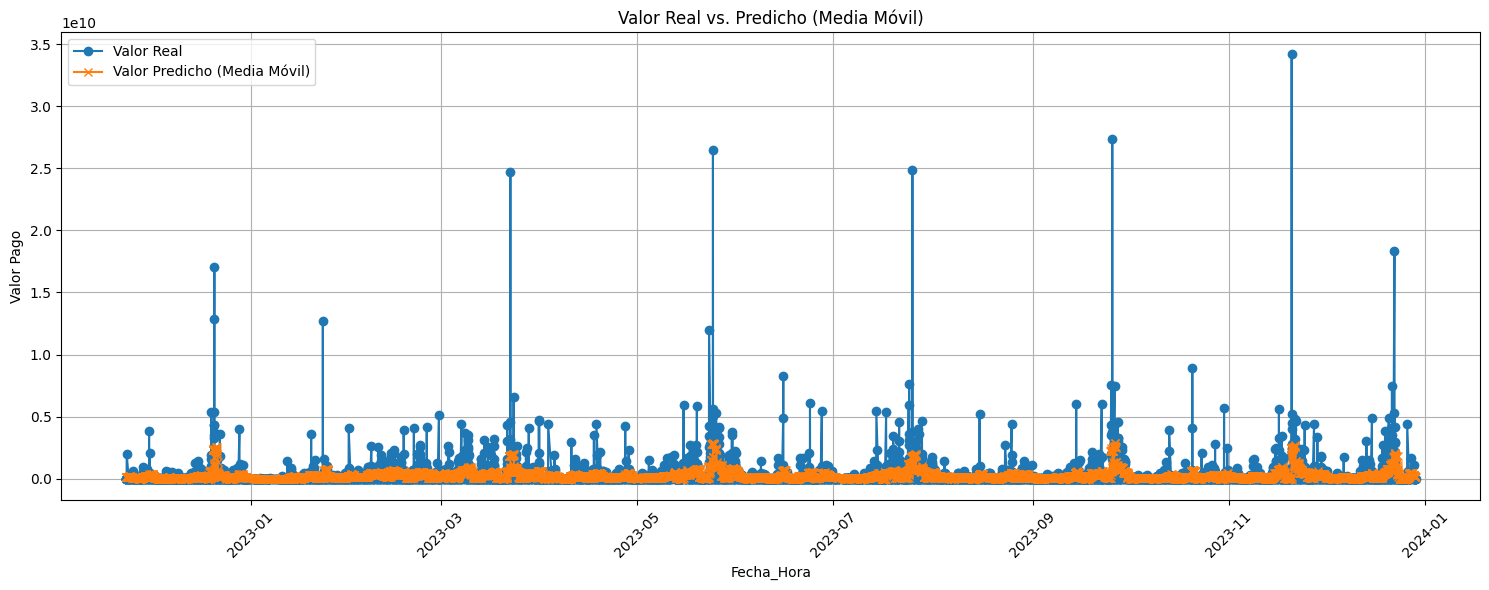

In [ ]:
# Obtener los últimos 720 data points de comparison_df
# 24 horas * 30 días/mes * 12 meses = 8640 horas/mes
last_8640_points = comparison_df.tail(8640)

# Gráfico reales vs predichos
plt.figure(figsize=(15, 6))
plt.plot(last_8640_points.index, last_8640_points['Valor Real'], label='Valor Real', marker='o')
plt.plot(last_8640_points.index, last_8640_points['Valor Predicho (Media Móvil)'], label='Valor Predicho (Media Móvil)', marker='x')

plt.title('Valor Real vs. Predicho (Media Móvil)')
plt.xlabel('Fecha_Hora')
plt.ylabel('Valor Pago')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### EWMA

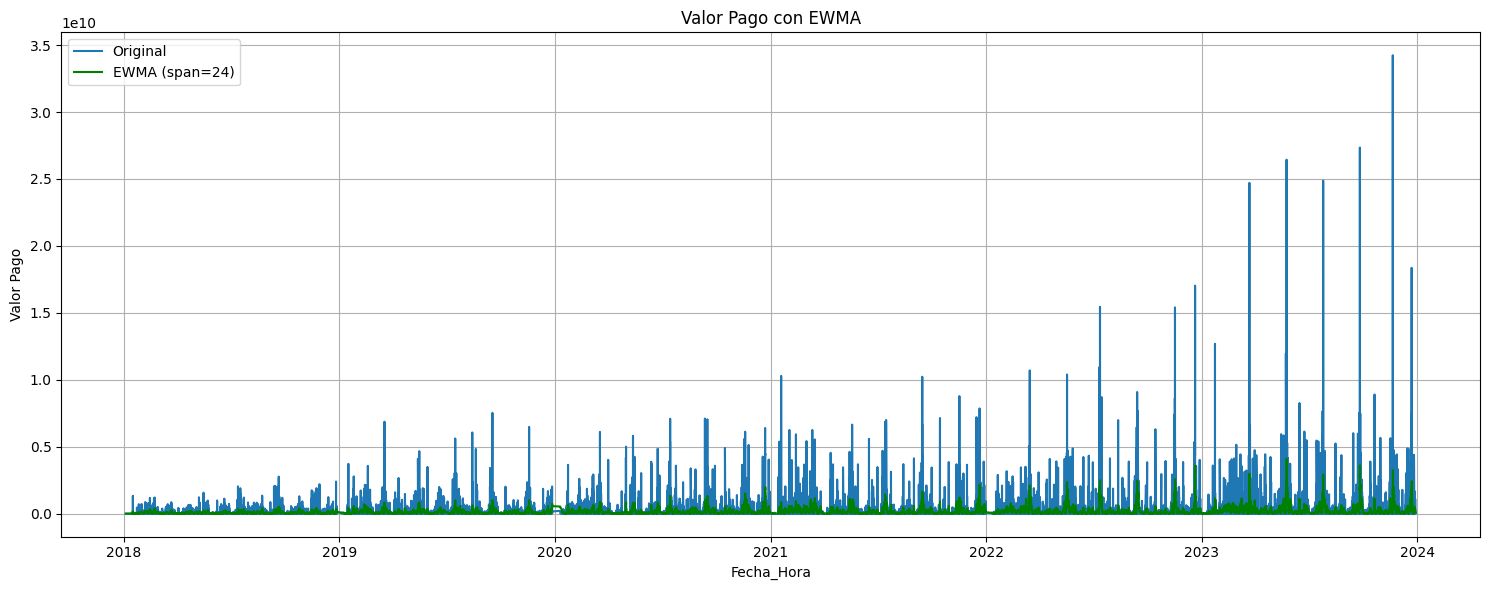

In [ ]:
# Aplicar Exponentially Weighted Moving Average (EWMA)
# Puedes ajustar 'span' o 'alpha' para controlar el suavizado
# span: especifica el periodo de ajuste (por ejemplo, 24 para un día si los datos son horarios)
# alpha: factor de suavizado directo (0 < alpha <= 1)
ewma = dataset0_indexed['Valor Pago'].ewm(span=24).mean()

# Graficar la serie de tiempo original junto con la EWMA
plt.figure(figsize=(15, 6))
plt.plot(dataset0_indexed['Valor Pago'], label='Original')
plt.plot(ewma, label='EWMA (span=24)', color='green')
plt.title('Valor Pago con EWMA')
plt.xlabel('Fecha_Hora')
plt.ylabel('Valor Pago')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Puedes probar con diferentes valores de span o alpha
# ewma_weekly = dataset0_indexed['Valor Pago'].ewm(span=168).mean() # Ejemplo para EWMA semanal

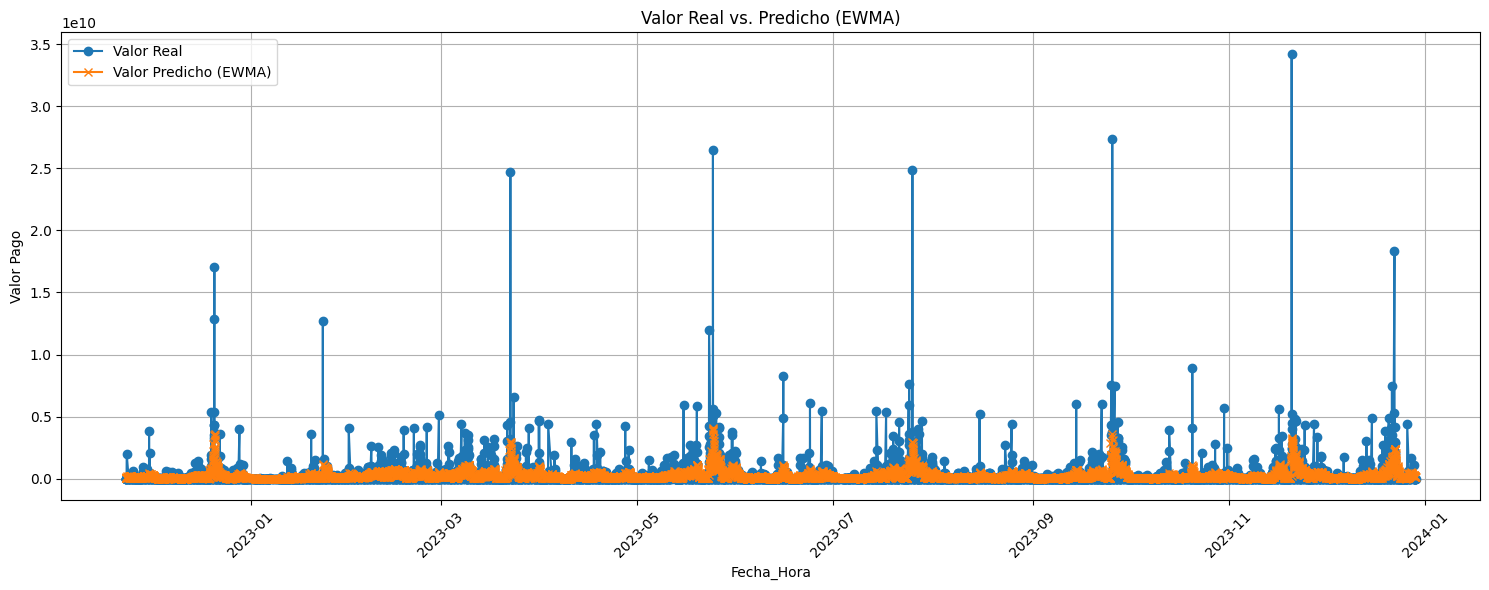


RMSE: 868235301.97
MAPE: 307014.92%
MAE: 267879940.88
sMAPE: 115.39%
MASE: 1.07
R-squared: 0.21


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Asegura EWMA y dataset0_indexed están disponibles
# Si no, ejecutar las celdas que calculan EWMA y preparar Fecha_Hora como index

# Alinea el EWMA con los datos originales.
ewma_aligned = ewma.dropna()
actual_values_aligned_for_ewma = dataset0_indexed['Valor Pago'][ewma_aligned.index]

# Obtener los últimos 720 puntos de datos para la comparación
last_720_actual = actual_values_aligned_for_ewma.tail(8640)
last_720_ewma = ewma_aligned.tail(8640)

# Crear un DataFrame para la comparación.
comparison_df_ewma = pd.DataFrame({
    'Valor Real': last_720_actual,
    'Valor Predicho (EWMA)': last_720_ewma
})

# Graficar los ultimos 720 puntos reales vs. predichos por EWMA
plt.figure(figsize=(15, 6))
plt.plot(comparison_df_ewma.index, comparison_df_ewma['Valor Real'], label='Valor Real', marker='o')
plt.plot(comparison_df_ewma.index, comparison_df_ewma['Valor Predicho (EWMA)'], label='Valor Predicho (EWMA)', marker='x')

plt.title('Valor Real vs. Predicho (EWMA)')
plt.xlabel('Fecha_Hora')
plt.ylabel('Valor Pago')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcular RMSE para los últimos 720 puntos
rmse_ewma = np.sqrt(mean_squared_error(last_720_actual, last_720_ewma))
print(f"\nRMSE: {rmse_ewma:.2f}")

# Calcular MAPE para los últimos 720 puntos (manejando posible división por cero)
epsilon = 1e-10
mape_ewma = np.mean(np.abs((last_720_actual - last_720_ewma) / (last_720_actual + epsilon))) * 100
print(f"MAPE: {mape_ewma:.2f}%")

# Calcular MAE para los últimos 720 puntos.
mae_ewma = mean_absolute_error(last_720_actual, last_720_ewma)
print(f"MAE: {mae_ewma:.2f}")

# Calcular sMAPE para los últimos 720 puntos (manejando posible división por cero)
smape_ewma = np.mean(2 * np.abs(last_720_ewma - last_720_actual) / (np.abs(last_720_actual) + np.abs(last_720_ewma) + epsilon)) * 100
print(f"sMAPE: {smape_ewma:.2f}%")

# Calcular MASE para los últimos 720 puntos (requiere una línea base de pronóstico ingenuo)
# Usando un pronóstico ingenuo del último valor observado como línea base para MASE
naive_forecast_ewma = last_720_actual.shift(1).dropna()
actual_values_for_mase_ewma = last_720_actual[naive_forecast_ewma.index]
mae_naive_ewma = np.mean(np.abs(actual_values_for_mase_ewma - naive_forecast_ewma))

# Manejar el caso en que mae_naive_ewma sea cero.
if mae_naive_ewma == 0:
    mase_ewma = np.nan # MASE es indefinido si el pronóstico ingenuo tiene error cero
    print("MASE: Indefinido (El pronóstico ingenuo tiene error cero)")
else:
    mase_ewma = mae_ewma / mae_naive_ewma
    print(f"MASE: {mase_ewma:.2f}")

# Calcular R-squared para los últimos 720 puntos.
r2_ewma = r2_score(last_720_actual, last_720_ewma)
print(f"R-squared: {r2_ewma:.2f}")

### ¿Cómo separar los datos para propósitos de validación?

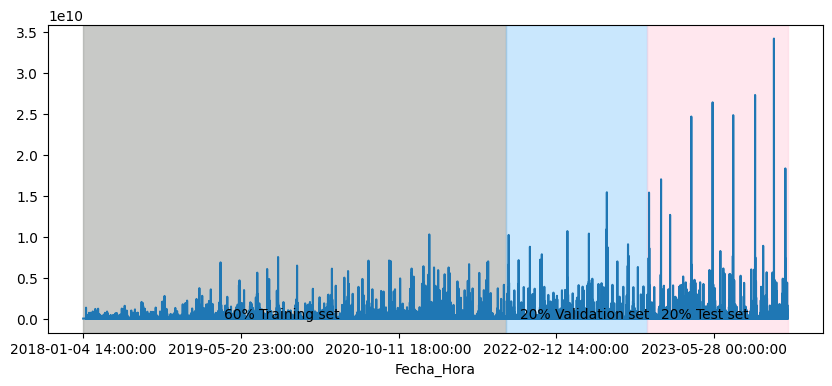

In [ ]:
from local.lib import DataPreparationRNN
dataset0 = pd.read_csv("https://raw.githubusercontent.com/algoritmomaestro/Proyecto_DeepLearning/refs/heads/main/datos_recaudo_total.csv", usecols=[0,1], engine='python', skipfooter=3)
DataPreparationRNN.PlotValidationTimeSeries(dataset0)